In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [3]:
df = pd.read_csv("housing_price_dataset.csv")

In [5]:
df.head(10)

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065
5,2095,2,3,Suburb,2020,198208.803907
6,2724,2,1,Suburb,1993,343429.319110
7,2044,4,3,Rural,1957,184992.321268
8,2638,4,3,Urban,1959,377998.588152
9,1121,5,2,Urban,2004,95961.926014


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


In [14]:
df.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


In [17]:
df.isnull().sum()

SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

In [13]:
df.groupby('Neighborhood').size()

Neighborhood
Rural     16676
Suburb    16721
Urban     16603
dtype: int64

 ### Since there are 3 categorical values for 'Neighborhood', we will convert them to numerical values
 
#### Also the Neighborhood is ordinal category

In [19]:
encoder = LabelEncoder()
df['Neighborhood'] = encoder.fit_transform(df['Neighborhood'])

In [20]:
df.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,0,1969,215355.283618
1,2459,3,2,0,1980,195014.221626
2,1860,2,1,1,1970,306891.012076
3,2294,2,1,2,1996,206786.787153
4,2130,5,2,1,2001,272436.239065


### Let's see how closely each features are related using correlation

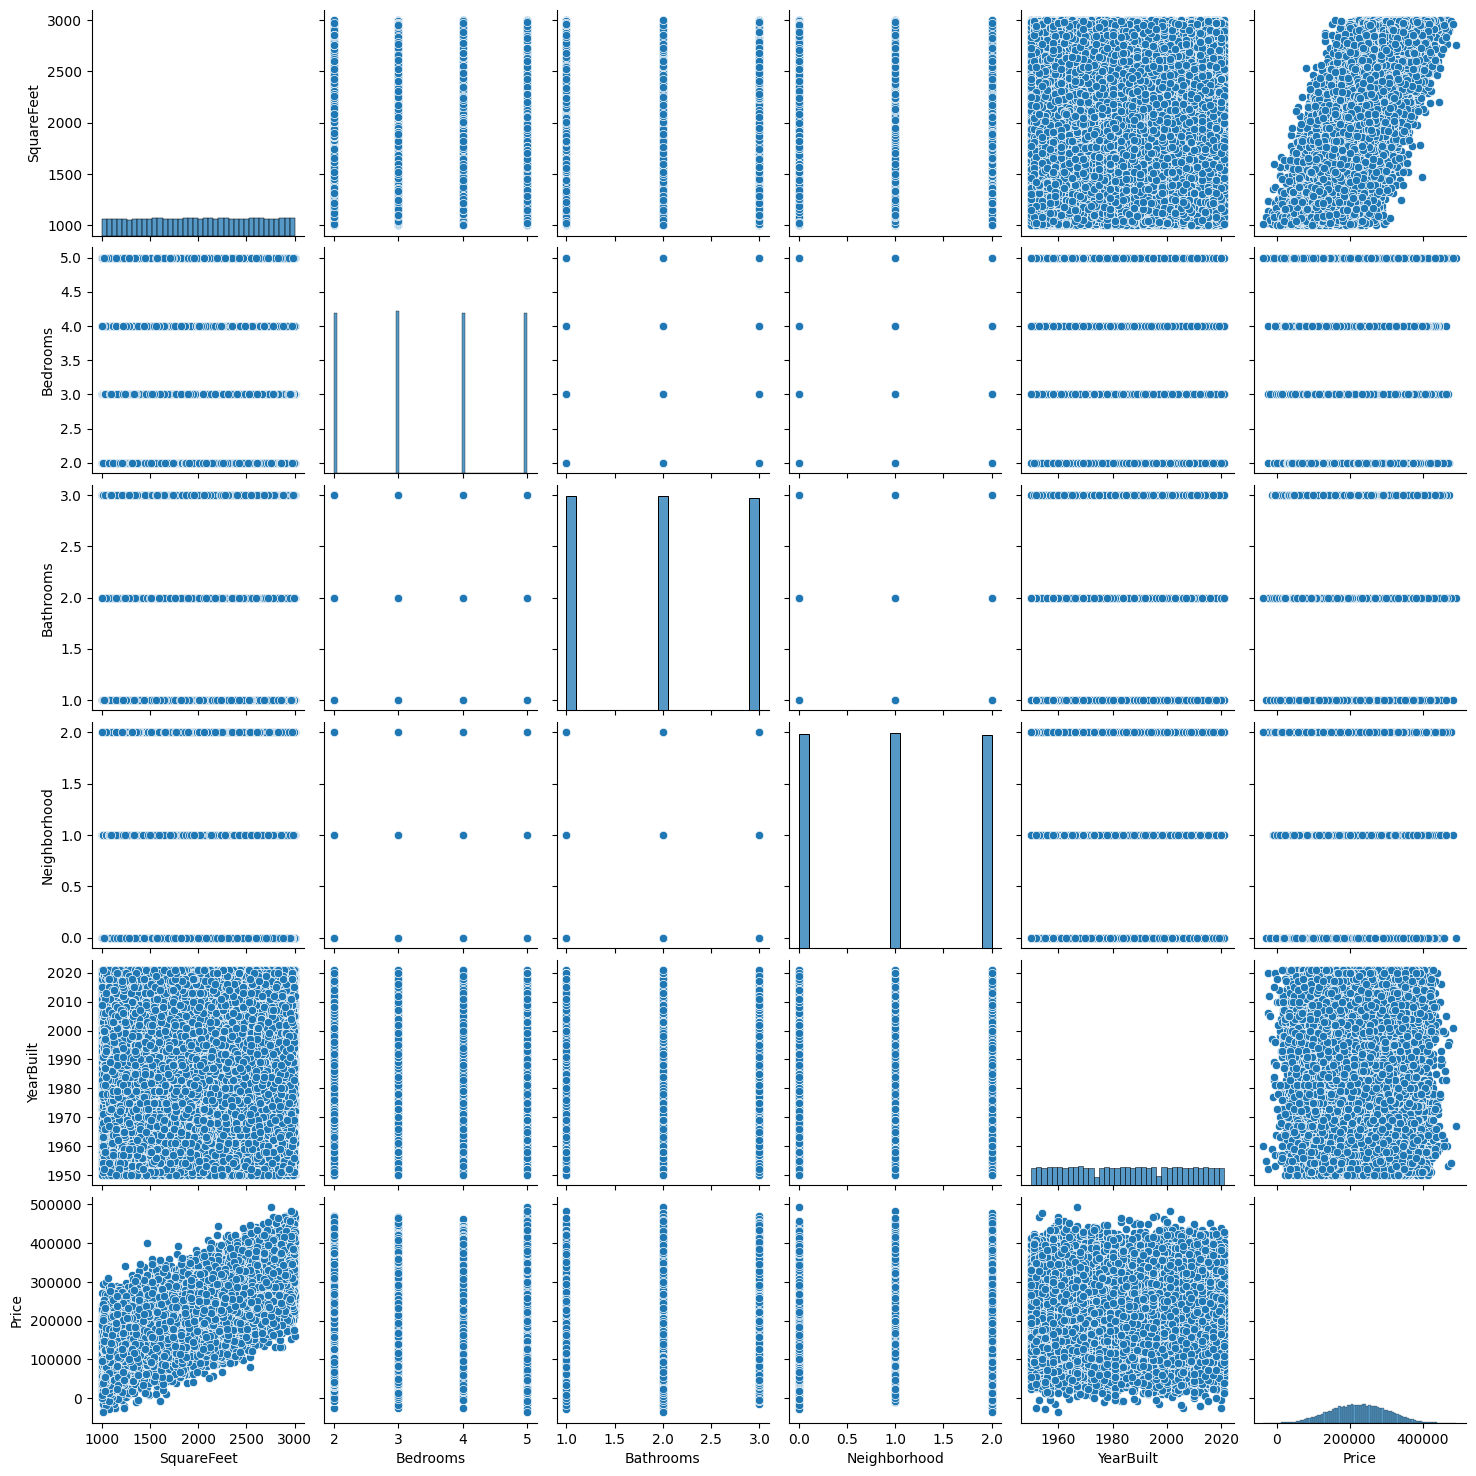

In [22]:
sns.pairplot(df)

#### It's clear that 'Price' and 'Squarefeet' are highly correlated

<Axes: >

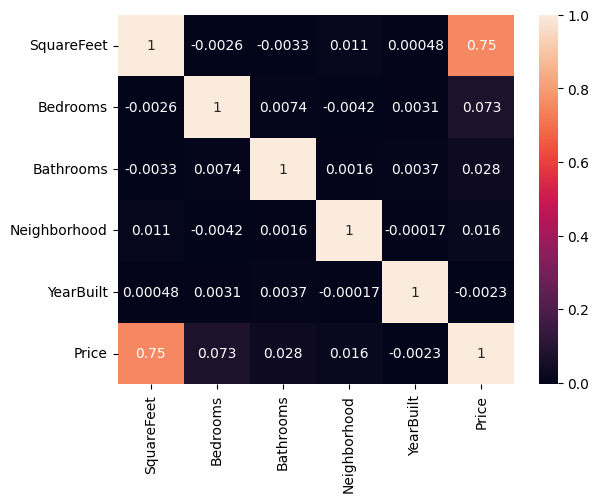

In [24]:
sns.heatmap(df.corr(), annot=True)

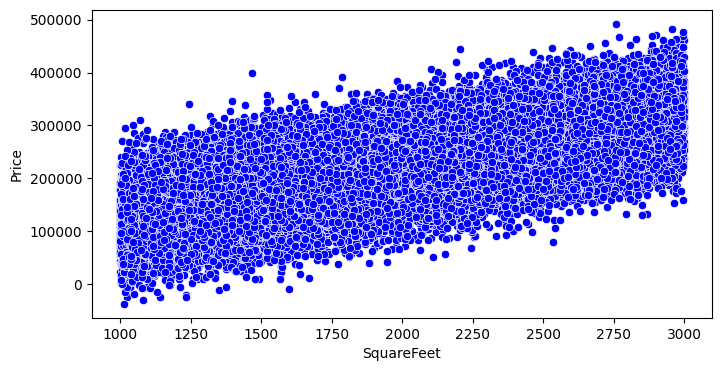

In [29]:
plt.figure(figsize=(8,4))
sns.scatterplot(x='SquareFeet',y='Price',data=df,color='blue')
plt.show()

In [47]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(['Price'], axis = 1),df['Price'],test_size=0.2,random_state=2)


In [48]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [49]:
linear_model.score(X_test, y_test)

0.5632350593771948

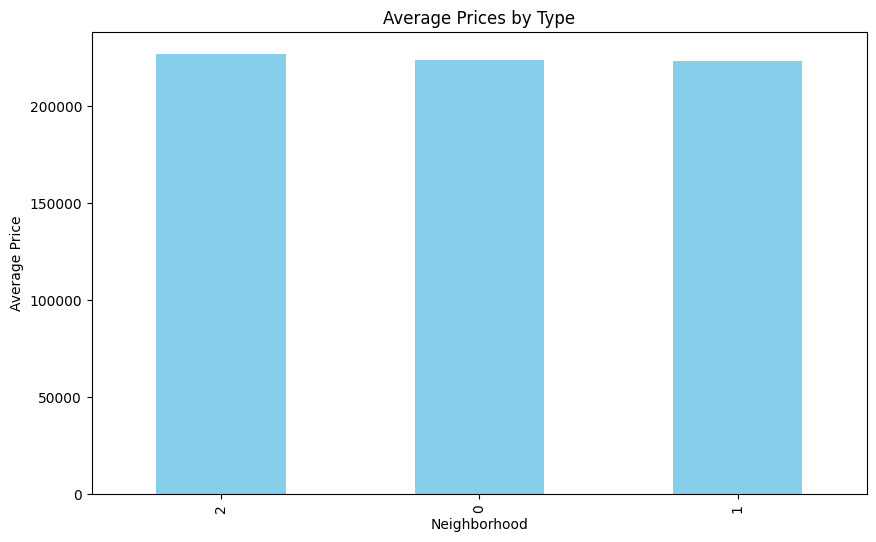

In [75]:
average_prices = df.groupby('Neighborhood')['Price'].mean().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
average_prices.plot(kind='bar', color='skyblue')
plt.title('Average Prices by Type')
plt.xlabel('Neighborhood')
plt.ylabel('Average Price')
plt.show()

### This shows that the type of Neighborhood has almost no relation with the Price




## Since only the feature SquareFeet seem to decide the House Price, let's train our model on only one variable


In [80]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(df[['SquareFeet']], df['Price'], test_size=0.2, random_state = 2)

univariate_linear_model = LinearRegression()
univariate_linear_model.fit(X_train1, y_train1)

LinearRegression()

In [82]:
univariate_linear_model.score(X_test1, y_test1)

0.55655468366962

### We can see that there is only a small difference in score